In [4]:
# Data processing
import pandas as pd
import numpy as np
import re

# NLP
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [5]:
# GANTI path sesuai lokasi dataset kamu
df = pd.read_csv("data/data_youtube_ijazah_jokowi.csv")

df.head()


,platform,comment,timestamp,username,sentimen
0,YouTube,Roy Suryo pantas di jeblos kan ke PENJARA,1 menit yang lalu,@marubaedisiahaan3435,Netral
1,YouTube,Kopok calon penguni penjara roy cs..semoga gro...,1 menit yang lalu,@enyjulaikah7086,Netral
2,YouTube,"Orang yg ngotot dgn izazah jokowi, pasti ada n...",1 menit yang lalu,@tsinurat-kv2vu,Netral
3,YouTube,Salut buat Pak Suryo \r\nKonsisten melawan oli...,1 menit yang lalu,@BadutSurabayaSidoarjo,Netral
4,YouTube,Orang gila ini mau ditunjukkan yg asli tetep a...,1 menit yang lalu,@bagiokirun5176,Netral


In [6]:
# Cell 3 - Normalisasi nama kolom + tampilkan info & value_counts dengan aman
# (Paste ini utuh ke cell no.3)

# 1) Normalisasi nama kolom: hapus spasi dan ubah jadi lowercase
df.columns = df.columns.str.strip().str.lower()

# 2) Tampilkan daftar kolom setelah normalisasi (verifikasi cepat)
print("Kolom setelah normalisasi:", df.columns.tolist())
print("-" * 60)

# 3) Jika kolom 'sentimen' ada, ganti namanya menjadi 'sentiment' untuk konsistensi
if 'sentimen' in df.columns:
    df.rename(columns={'sentimen': 'sentiment'}, inplace=True)
    print("Rename: 'sentimen' -> 'sentiment'")

# 4) Tampilkan info DataFrame dan value_counts untuk kolom 'sentiment' (jika ada)
print()
df.info()
print()

if 'sentiment' in df.columns:
    print("Value counts untuk kolom 'sentiment':")
    print(df['sentiment'].value_counts())
else:
    print("Kolom 'sentiment' tidak ditemukan. Kolom tersedia:", df.columns.tolist())


Kolom setelah normalisasi: ['platform', 'comment', 'timestamp', 'username', 'sentimen']
------------------------------------------------------------
Rename: 'sentimen' -> 'sentiment'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   platform   1000 non-null   object
 1   comment    1000 non-null   object
 2   timestamp  1000 non-null   object
 3   username   1000 non-null   object
 4   sentiment  1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB

Value counts untuk kolom 'sentiment':
sentiment
Netral     976
Positif     17
Negatif      7
Name: count, dtype: int64


In [7]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stopwords])
    text = stemmer.stem(text)
    return text

df['cleaned'] = df['comment'].apply(preprocess_text)


In [8]:
df[['comment', 'cleaned']].head(10)


,comment,cleaned
0,Roy Suryo pantas di jeblos kan ke PENJARA,roy suryo pantas jeblos kan penjara
1,Kopok calon penguni penjara roy cs..semoga gro...,kopok calon uni penjara roy cssemoga grombolan...
2,"Orang yg ngotot dgn izazah jokowi, pasti ada n...",orang yg ngotot dgn izazah jokowi niat tentu a...
3,Salut buat Pak Suryo \r\nKonsisten melawan oli...,salut buat pak suryo konsisten lawan oligarki
4,Orang gila ini mau ditunjukkan yg asli tetep a...,orang gila mau tunjuk yg asli tetep aja bilang...
5,Roy suryo ! Maksutnya orang salah ga boleh dih...,roy suryo maksutnya orang salah ga hukum karna...
6,Kalo nganggur kerja njeng....bukan cari gara2 ...,kalo nganggur kerja njengbukan cari gara mulu ...
7,"Semangat, para pejuang pengungkap kebenaraan.",semangat juang ungkap benara
8,Susah di kasih tau bak apalagi jubirnya past...,susah kasih tau bak jubirnya tdk mau paham lah
9,Ya Allah tunjukan kuasamu kebenaran itu pasti ...,allah tunjuk kuasa benar kau buka busuk hancur...


In [9]:
X = df['cleaned']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Latih:", len(X_train))
print("Data Uji:", len(X_test))


Data Latih: 800
Data Uji: 200


In [10]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [11]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_tfidf, y_train)

y_pred_linear = svm_linear.predict(X_test_tfidf)

print("SVM Linear Accuracy:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))


SVM Linear Accuracy: 0.975
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00         2
      Netral       0.97      1.00      0.99       195
     Positif       0.00      0.00      0.00         3

    accuracy                           0.97       200
   macro avg       0.33      0.33      0.33       200
weighted avg       0.95      0.97      0.96       200



e:\KODINGAN\ijazah jokowi\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\KODINGAN\ijazah jokowi\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\KODINGAN\ijazah jokowi\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


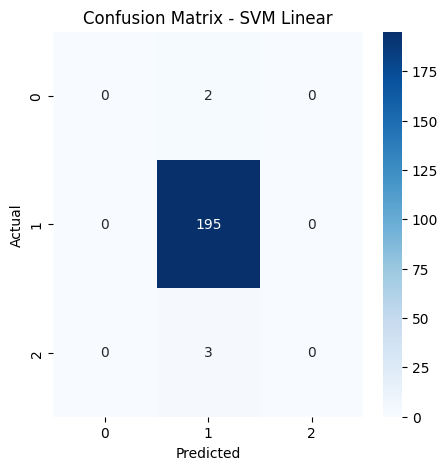

In [12]:
cm = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM Linear")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [13]:
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1)
svm_rbf.fit(X_train_tfidf, y_train)

y_pred_rbf = svm_rbf.predict(X_test_tfidf)

print("SVM RBF Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))


SVM RBF Accuracy: 0.975
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00         2
      Netral       0.97      1.00      0.99       195
     Positif       0.00      0.00      0.00         3

    accuracy                           0.97       200
   macro avg       0.33      0.33      0.33       200
weighted avg       0.95      0.97      0.96       200



e:\KODINGAN\ijazah jokowi\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\KODINGAN\ijazah jokowi\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\KODINGAN\ijazah jokowi\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
print("Akurasi Linear :", accuracy_score(y_test, y_pred_linear))
print("Akurasi RBF    :", accuracy_score(y_test, y_pred_rbf))


Akurasi Linear : 0.975
Akurasi RBF    : 0.975


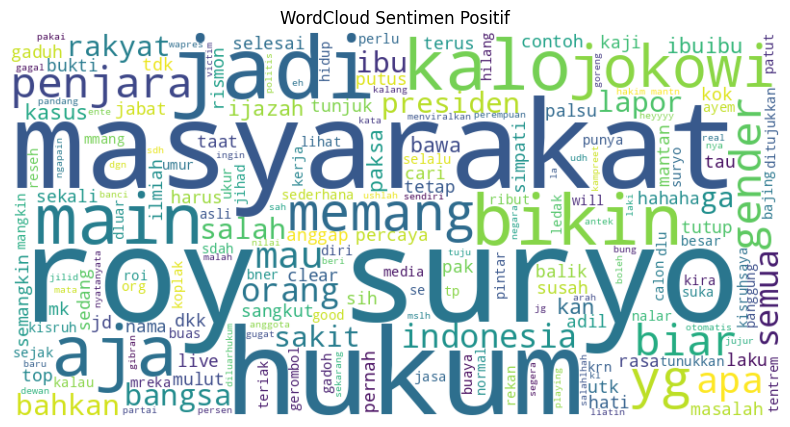

In [15]:
text_pos = ' '.join(df[df['sentiment']=='Positif']['cleaned'])

wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Sentimen Positif")
plt.show()


In [16]:
error_df = X_test[y_test != y_pred_linear]
error_df.head(5)


230    kalo mau tunjuk media tv ijazah asli jokowi la...
67              tunjuk media harus kalo perlu bikin live
887    duuuh lihat muka roy suryo jadi pingin muntah ...
870    ngaruh lah bro kalo ijazah palsu arti bohong r...
158    jasa apa orang reseh roi suryo rekan bangsa ra...
Name: cleaned, dtype: object